In [1]:
"""
There appears to be a bifurcation in the I-O plots for a given set of autapse parameters

- Can estimate this transition based on discontinuities of the derivative.

F_steady: -> negative area under the 1st derivative plot is non-zero for the select autapse parameters
F_instant -> There is a bifurcation where the neuron becomes extra sensitive to inputs with an autapse.
        Here the slope at the start of the curve is very steep!


"""



import sys
sys.path.append("..//")

from batchAQUA_general import batchAQUA
from AQUA_general import AQUA
from stimulus import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import pickle
import random


from simulation import get_F

In [2]:
# initial tests on RS_int

neuron = "RS_int"
out_dir = f".//{neuron}//"

filename = f"{neuron}_test.pickle"
with open(filename, 'rb') as file:
    df = pickle.load(file)

print(df.keys())
print(df["F_steady"])


Index(['e', 'f', 'tau', 'I_h', 'F_instant', 'F_steady', 'autapse current',
       'autapse delay'],
      dtype='object')
0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
1695    99.700897
1696    94.786730
1697    94.339623
1698    92.850511
1699    90.661831
Name: F_steady, Length: 3700, dtype: float64


[0.  0.1 0.2 0.5]
[  0.  50. 150. 250.]


Text(0.5, 0, 'Injected Current [pA]')

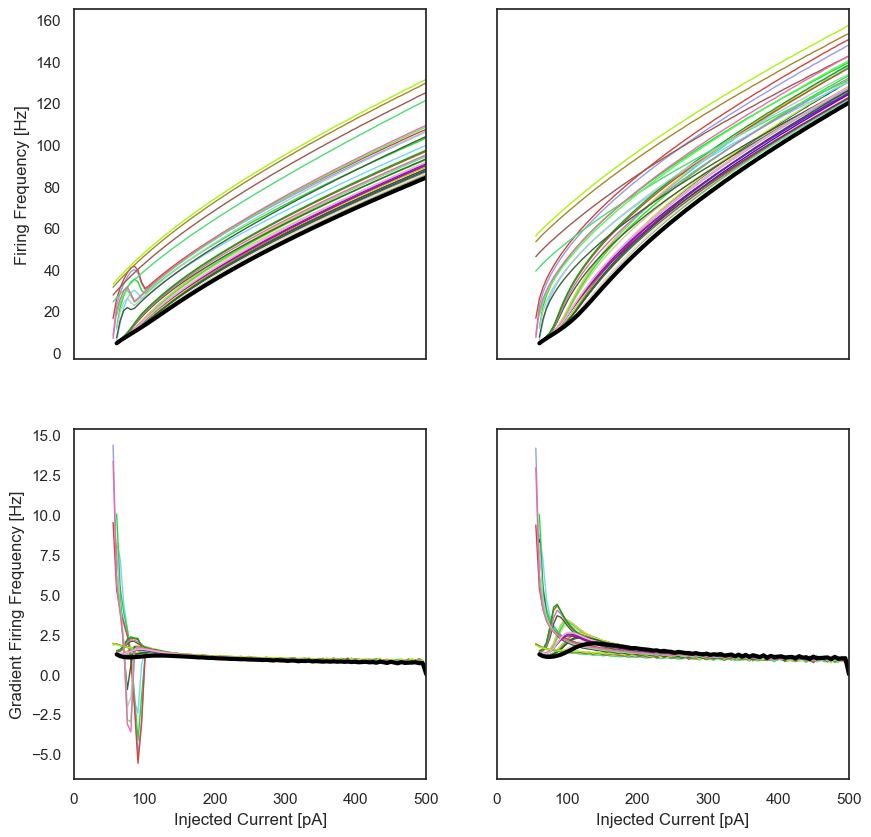

In [3]:
### EXTRACT relevant data

e_vals = df["e"].unique()
f_vals = df["f"].unique()
tau_vals = df["tau"].unique()

print(e_vals)
print(f_vals)

# Get plotting data in I-O curves
fig, ax = plt.subplots(2, 2, figsize = (10, 10), sharex = True, sharey = 'row')

for e in np.flip(e_vals):
    for f in np.flip(f_vals):
        for tau in np.flip(tau_vals):
            # colours for plotting
            if e == 0.0 and f == 0.0 and tau == 0.0:
                colour = (0., 0., 0.)
                linewidth = 3
            else:
                colour = tuple(np.random.rand(3))   # colour for individual neurons
                linewidth = 1
        
            # get relevant neuron with autapse parameters
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)].copy()
            if sub_df.empty:
                continue

            sub_df.sort_values(by = ["I_h"])

            I_h = np.array(sub_df["I_h"])
            F_steady = np.array(sub_df["F_steady"])
            grad_f_steady = np.ediff1d(F_steady, to_end = 0.0)
            F_instant = np.array(sub_df["F_instant"])
            grad_f_instant = np.ediff1d(F_instant, to_end = 0.0)

            ax[0, 0].plot(I_h, F_steady, c = colour, linewidth = linewidth)
            ax[0, 1].plot(I_h, F_instant, c = colour, linewidth = linewidth)
            ax[1, 0].plot(I_h, grad_f_steady, c = colour, linewidth = linewidth)
            ax[1, 1].plot(I_h, grad_f_instant, c = colour, linewidth = linewidth)


ax[0, 0].set_xlim((np.min(I_h), np.max(I_h)))
ax[0, 0].set_ylabel("Firing Frequency [Hz]")
ax[1, 0].set_ylabel("Gradient Firing Frequency [Hz]")
ax[1, 0].set_xlabel("Injected Current [pA]")
ax[1, 1].set_xlabel("Injected Current [pA]")




In [48]:
### EXTRACT relevant data

e_vals = df["e"].unique()
e_vals = np.delete(e_vals, 0)
f_vals = df["f"].unique()
f_vals = np.delete(f_vals, 0)
tau_vals = df["tau"].unique()

print(e_vals)
print(f_vals)

N_neurons = 1 + len(e_vals)*len(f_vals)*len(tau_vals)
print(f"N_neurons: {N_neurons}")


autapse_current = np.zeros(N_neurons)
autapse_delay = np.zeros(N_neurons)
instant_gradient = np.zeros(N_neurons)
area_steady = np.zeros(N_neurons)

count = 0
for e in np.flip(e_vals):
    for f in np.flip(f_vals):
        for tau in np.flip(tau_vals):
        
            # get relevant neuron with autapse parameters
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)].copy()
            if sub_df.empty:
                continue
            else:
                sub_df.sort_values(by = ["I_h"])

                F_steady = np.array(sub_df["F_steady"])
                grad_f_steady = np.ediff1d(F_steady, to_end = 0.0)
                F_instant = np.array(sub_df["F_instant"])
                grad_f_instant = np.ediff1d(F_instant, to_end = 0.0)

                autapse_current[count] = sub_df["autapse current"].unique()
                autapse_delay[count] = sub_df["autapse delay"].unique()
                instant_gradient[count] = grad_f_instant[~np.isnan(grad_f_instant)][0]  # first non-nan element
                area_steady[count] = np.abs(np.sum(grad_f_steady[(~np.isnan(grad_f_steady)) & (grad_f_steady < 0.)]))     # essentially the area under the steady gradient curve

                count += 1

autapse_current = np.nan_to_num(autapse_current, 0.)
autapse_delay = np.nan_to_num(autapse_delay, 0.)
sort_idx = np.argsort(autapse_current)

autapse_current = np.round(autapse_current, 0)
autapse_delay = np.round(autapse_delay, 2)
print(autapse_delay)

dict = {"autapse current": autapse_current[sort_idx].astype(str),
        "autapse delay": autapse_delay[sort_idx],
        "instant gradient": instant_gradient[sort_idx],
        "area steady": area_steady[sort_idx]}
new_df = pd.DataFrame(dict)

WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_1692\1301363074.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  autapse_current[count] = sub_df["autapse current"].unique()
 [py.warnings]
WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_1692\1301363074.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  autapse_delay[count] = sub_df["autapse delay"].unique()
 [py.warnings]


[0.1 0.2 0.5]
[ 50. 150. 250.]
N_neurons: 37
[ 5.39  3.39  1.89  1.39  5.39  3.39  1.89  1.39  5.39  3.39  1.89  1.39
  7.47  5.47  3.97  3.47  7.47  5.47  3.97  3.47  7.47  5.47  3.97  3.47
 10.93  8.93  7.43  6.93 10.93  8.93  7.43  6.93 10.93  8.93  7.43  6.93
  0.  ]


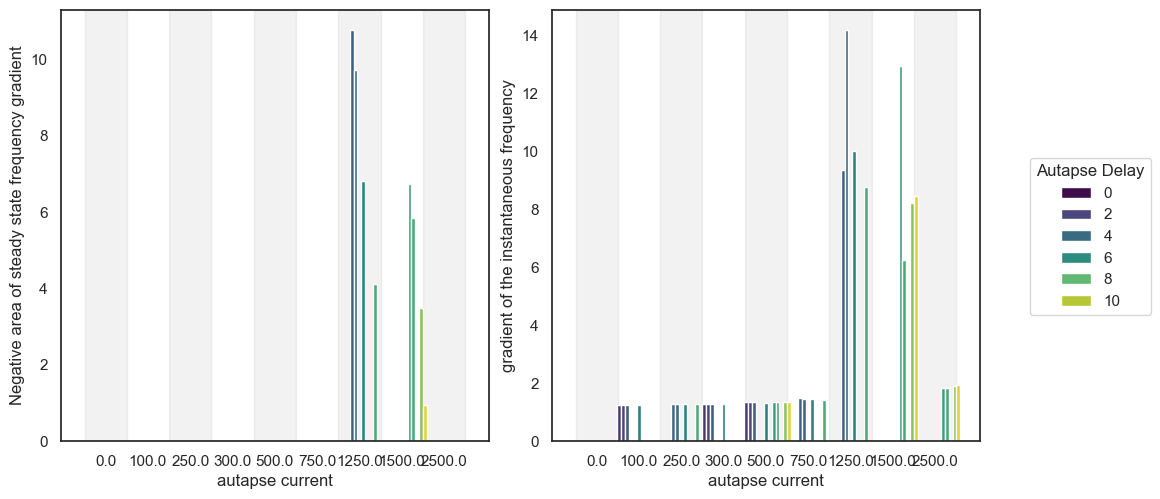

In [49]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
plt.tight_layout()

sns.barplot(data = new_df, x = "autapse current", y = "area steady", hue = "autapse delay", palette = 'viridis', ax = ax[0], width = 1.2)
sns.barplot(data = new_df, x = "autapse current", y = "instant gradient", hue = "autapse delay", palette = 'viridis', ax = ax[1], width = 1.2, legend = False)

# create a legend for the whole figure
handles, labels = ax[0].get_legend_handles_labels()     # get legend from ax[0]
ax[0].get_legend().remove()                             # delete legend data
fig.legend(handles, labels, title='Autapse Delay', loc='center right', 
           bbox_to_anchor=(1.15, 0.5))

# Loop through the number of categories on your x-axis
for i in range(len(new_df["autapse current"].unique())):
    if i % 2 == 0:
        ax[0].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)
        ax[1].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

ax[0].set_ylabel("Negative area of steady state frequency gradient")
ax[1].set_ylabel("gradient of the instantaneous frequency")
plt.show()